# 03 , Modélisation & évaluation

On prédit `arr_del15` (retard ≥ 15 min à l'arrivée) à partir des seules features connues *avant*
le vol. Tout l'entraînement est dans `src/train.py` ; ici on **analyse** le modèle sauvegardé.

Choix méthodologiques :
- **Split temporel** : entraînement sur janv vers oct 2024, test sur nov-déc (on ne prédit jamais le
 passé avec le futur).
- **Déséquilibre** (~21 % de retards) vers `class_weight="balanced"` et évaluation en AUC / PR-AUC.
- Aéroports/compagnies à forte cardinalité (348 aéroports) encodés par **TargetEncoder**
 (encodage par la cible, validation croisée interne anti-fuite).
 Réf : <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html>


In [1]:
import duckdb, pandas as pd, numpy as np, joblib, json, matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.inspection import permutation_importance
FEATURES = ["airline","origin","dest","month","day_of_week","dep_hour","distance","crs_elapsed"]
db = duckdb.connect("../data/processed/flights.duckdb", read_only=True)
model = joblib.load("../models/model.joblib")
meta = json.load(open("../models/meta.json"))

## 1. Comparaison des modèles

Trois approches, du plus naïf au meilleur (résultats produits par `src/train.py`) :

In [2]:
pd.read_csv("../models/resultats.csv")

,modele,AUC,PR_AUC,F1,accuracy,t_train_s
0,Dummy (majoritaire),0.5000,0.1795,0.0000,0.8205,NaN
1,Regression logistique,0.5993,0.2321,0.3118,0.6452,132.5
2,HistGradientBoosting,0.6208,0.2514,0.2306,0.7728,71.5


Lecture :
- Le **Dummy** (prédit toujours "à l'heure") atteint 82 % d'accuracy mais **AUC = 0.5** vers l'accuracy
 seule est trompeuse sur des classes déséquilibrées.
- La **régression logistique** capte un signal linéaire (AUC 0.60).
- **HistGradientBoosting** est le meilleur (AUC 0.62) en captant les interactions
 (compagnie × aéroport × heure), et s'entraîne en ~70 s sur 5,8 M de vols.

On retient donc **HistGradientBoosting**. On recharge le jeu de test pour l'analyser en détail.

In [3]:
test = db.execute(f"SELECT {','.join(FEATURES+['arr_del15'])} FROM flights "
 "WHERE flight_date>='2024-11-01' AND cancelled=0 AND diverted=0 "
 "AND arr_del15 IS NOT NULL AND crs_elapsed IS NOT NULL").df()
proba = model.predict_proba(test[FEATURES])[:,1]
y = test.arr_del15.values
print("Test :", f"{len(y):,}", "vols | taux de retard réel :", round(y.mean(),3))

Test : 1,156,765 vols | taux de retard réel : 0.179


## 2. Courbe ROC

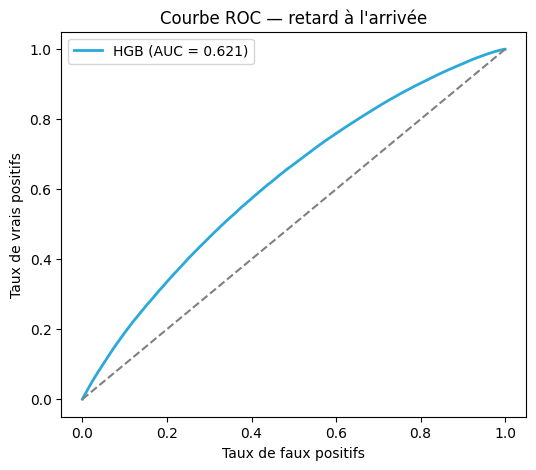

In [4]:
fpr, tpr, _ = roc_curve(y, proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="#2aa9db", lw=2, label=f"HGB (AUC = {auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1], "--", color="gray")
plt.xlabel("Taux de faux positifs"); plt.ylabel("Taux de vrais positifs"); plt.title("Courbe ROC , retard à l'arrivée")
plt.legend(); plt.show()

AUC ≈ 0.62 : le modèle est **nettement meilleur que le hasard**, mais loin d'être parfait.
C'est **attendu et honnête** : sans la **météo** ni l'état réel du trafic le jour J (données qu'on
n'a pas *avant* le vol), une grande partie du retard reste imprévisible. Le modèle capte la partie
"structurelle" (compagnie, aéroport, heure), pas les aléas.

## 3. Matrice de confusion

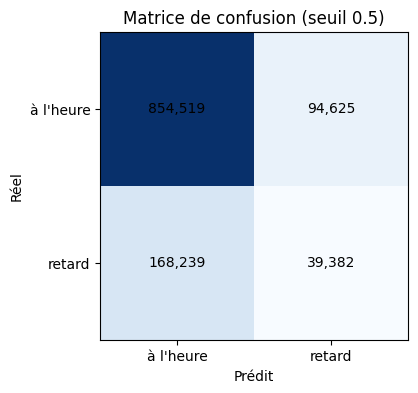

In [5]:
cm = confusion_matrix(y, (proba>=0.5).astype(int))
plt.figure(figsize=(4.5,4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
 for j in range(2): plt.text(j, i, f"{cm[i,j]:,}", ha="center", va="center")
plt.xticks([0,1], ["à l'heure","retard"]); plt.yticks([0,1], ["à l'heure","retard"])
plt.xlabel("Prédit"); plt.ylabel("Réel"); plt.title("Matrice de confusion (seuil 0.5)")
plt.show()

Avec `class_weight="balanced"`, le modèle attrape une bonne part des vrais retards au prix de
faux positifs , comportement voulu : pour un voyageur, être prévenu d'un risque est utile.

## 4. Quelles variables comptent ? (importance par permutation)

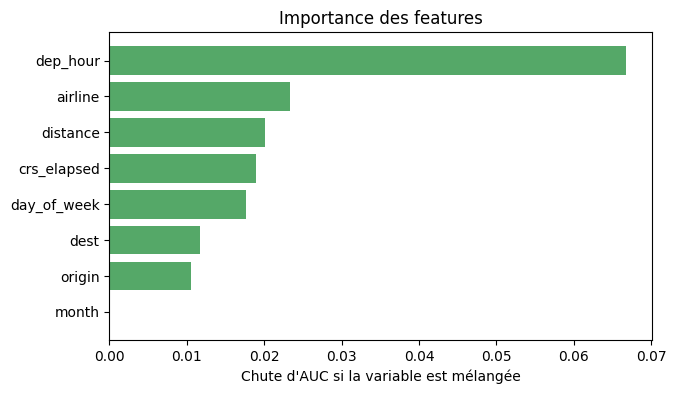

In [6]:
s = test.sample(40000, random_state=0)
imp = permutation_importance(model, s[FEATURES], s.arr_del15, n_repeats=3, scoring="roc_auc", random_state=0)
order = np.argsort(imp.importances_mean)
plt.figure(figsize=(7,4))
plt.barh([FEATURES[i] for i in order], imp.importances_mean[order], color="#55A868")
plt.xlabel("Chute d'AUC si la variable est mélangée"); plt.title("Importance des features"); plt.show()

`dep_hour`, la **compagnie** et l'**aéroport de départ** sont les variables les plus utiles , 
cohérent avec l'EDA (le retard monte au fil de la journée, et dépend de la compagnie/du hub).

## 5. Non supervisé , clusters d'aéroports (KMeans)

En parallèle, `src/unsupervised.py` regroupe les aéroports par profil et détecte les anomalies
(`IsolationForest`). Ces clusters colorent les aéroports sur la carte interactive.

In [7]:
cl = pd.read_csv("../models/airport_clusters.csv")
cl.groupby("cluster")[["n_flights","delay_rate","avg_delay","cancel_rate","avg_distance"]].mean().round(2)

,n_flights,delay_rate,avg_delay,cancel_rate,avg_distance
cluster,,,,,
0,18733.25,0.19,6.52,0.01,580.89
1,33191.58,0.15,2.35,0.01,826.16
2,34330.82,0.24,12.39,0.02,909.06
3,166032.04,0.22,7.16,0.01,915.35


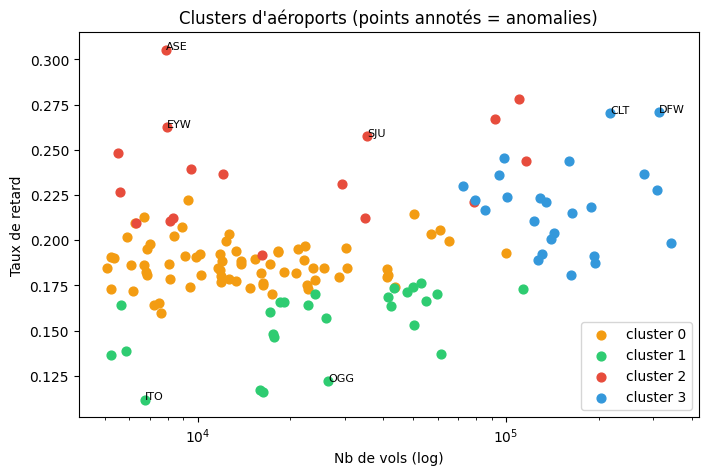

In [8]:
colors = ["#f39c12","#2ecc71","#e74c3c","#3498db"]
plt.figure(figsize=(8,5))
for c in sorted(cl.cluster.unique()):
 sub = cl[cl.cluster==c]
 plt.scatter(sub.n_flights, sub.delay_rate, s=40, color=colors[c], label=f"cluster {c}")
for _, r in cl[cl.anomalie==1].iterrows(): plt.annotate(r.iata, (r.n_flights, r.delay_rate), fontsize=8)
plt.xscale("log"); plt.xlabel("Nb de vols (log)"); plt.ylabel("Taux de retard")
plt.title("Clusters d'aéroports (points annotés = anomalies)"); plt.legend(); plt.show()

On distingue par ex. des aéroports **petits et fiables**, des **hubs très chargés**, et un
groupe à **forts retards**. Les anomalies (`IsolationForest`) ressortent : aéroports insulaires
(OGG, SJU, ITO), de montagne (ASE) ou méga-hubs atypiques (DFW, CLT).

## 6. Conclusion

- **Modèle retenu** : HistGradientBoosting (AUC 0.62), rapide (train ~70 s sur 5,8 M de lignes,
 inférence quasi instantanée vers adapté à l'API temps réel).
- **Limite assumée** : sans météo/trafic temps réel, le retard reste partiellement imprévisible.
- Le modèle et les clusters alimentent l'**interface carte** (`web/`) : avions colorés par le
 risque prédit + prédiction interactive via l'API.